## Imports

In [1]:
import pandas as pd
import math
from collections import deque
from collections import defaultdict
import heapq
import matplotlib.pyplot as plt
import networkx as nx

## Data Loading

In [2]:
# Define column names for the airport dataset based on OpenFlights documentation
airport_cols = ['AirportID','Name','City','Country','IATA','ICAO',
                'Latitude','Longitude','Altitude','Timezone','DST',
                'TzDatabase','Type','Source']

# Define column names for the flight routes dataset
route_cols = ['Airline','AirlineID','SourceAirport','SourceAirportID',
              'DestAirport','DestAirportID','Codeshare','Stops','Equipment']

# Load airport and route data from CSV files, treating '\N' as missing values (NaN)
airports_df = pd.read_csv('airports.csv', names=airport_cols, na_values='\\N')
routes_df = pd.read_csv('routes.csv', names=route_cols, na_values='\\N')

# Remove rows with missing critical information like IDs or geographic coordinates
airports_df = airports_df.dropna(subset=['AirportID','Latitude','Longitude'])
routes_df = routes_df.dropna(subset=['SourceAirportID','DestAirportID'])

# Convert ID columns to integer type to ensure consistency during graph construction
airports_df['AirportID'] = airports_df['AirportID'].astype(int)
routes_df['SourceAirportID'] = routes_df['SourceAirportID'].astype(int)
routes_df['DestAirportID'] = routes_df['DestAirportID'].astype(int)

# Display a summary of the successfully loaded and cleaned data
print("Data Loaded:", len(airports_df), "Airports,", len(routes_df), "Routes")


Data Loaded: 7698 Airports, 67240 Routes


## Geographic Distance Function

In [3]:
def haversine(lat1, lon1, lat2, lon2):
    
    # Earth's radius in kilometers
    R = 6371  
    # Convert latitude difference to radians
    dlat = math.radians(lat2 - lat1)
    # Convert longitude difference to radians
    dlon = math.radians(lon2 - lon1)
    # Calculate the square of half the chord length between the points
    a = math.sin(dlat / 2)**2 + math.cos(math.radians(lat1)) * \
        math.cos(math.radians(lat2)) * math.sin(dlon / 2)**2
    # Calculate the angular distance in radians
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    # Return the final distance in kilometers
    return R * c


## Graph Construction and Traversal

In [4]:
class FlightGraph:
    def __init__(self, airports_df, routes_df):
        # Initialize the adjacency list representing flight connections
        self.graph = {}
        # Initialize the dictionary to store airport coordinates as {AirportID: (Latitude, Longitude)}
        self.airports = {}

        # Populate the airports dictionary with coordinates from the DataFrame
        for _, row in airports_df.iterrows():
            airport_id = row["AirportID"]
            latitude = row["Latitude"]
            longitude = row["Longitude"]
            self.airports[airport_id] = (latitude, longitude)

        # Build the graph structure using route information and geographic distances
        for _, row in routes_df.iterrows():
            source = row["SourceAirportID"]
            dest = row["DestAirportID"]

            # Ensure both source and destination airports exist in our airport dictionary
            if source in self.airports and dest in self.airports:
                lat1, lon1 = self.airports[source]
                lat2, lon2 = self.airports[dest]
                # Calculate the geographic distance (weight) between airports using the Haversine formula
                distance = haversine(lat1, lon1, lat2, lon2)

                # Initialize the neighbor list for the source node if it doesn't exist
                if source not in self.graph:
                    self.graph[source] = []

                # Append the destination airport and distance tuple to the adjacency list
                self.graph[source].append((dest, distance))

    def bfs(self, start):
        # Set to track visited airport nodes to prevent infinite loops
        visited = set()
        # List to record the traversal order
        order = []
        # Double-ended queue initialized with the starting airport node
        queue = deque([start])

        # Dequeue elements and traverse the network level by level
        while queue:
            node = queue.popleft()

            if node not in visited:
                visited.add(node)
                order.append(node)

                # Traverse all neighbors of the current airport
                if node in self.graph:
                    for neighbor, _ in self.graph[node]:
                        if neighbor not in visited:
                            queue.append(neighbor)

        return order

    def dfs(self, start, visited=None, order=None):
        # Initialize visited set and order list during the initial function call
        if visited is None:
            visited = set()
        if order is None:
            order = []

        # Mark the current node as visited and append it to the traversal path
        visited.add(start)
        order.append(start)

        # Recursively traverse unvisited neighboring airports deep into the network
        if start in self.graph:
            for neighbor, _ in self.graph[start]:
                if neighbor not in visited:
                    self.dfs(neighbor, visited, order)

        return order


## Connected Components

In [5]:
def find_connected_components(graph_obj):
    # Initialize an adjacency list to construct an undirected version of the flight network
    undirected_adj = defaultdict(set)
    # Collect all available airport IDs from the graph's airport database
    all_nodes = set(graph_obj.airports.keys())

    # Build undirected connections since flight paths are directed but connectivity is evaluated bidirectionally
    for u in graph_obj.graph:
        for v, _ in graph_obj.graph[u]:
            undirected_adj[u].add(v)
            undirected_adj[v].add(u)

    # Set to keep track of visited nodes during the component search
    visited = set()
    # List to store all identified connected components
    components = []

    # Iterate over all airports to find separate connected subgraphs
    for node in all_nodes:
        if node not in visited:
            component = []
            stack = [node]

            # Run a Depth-First Search (DFS) iteratively using a stack to find all reachable nodes
            while stack:
                curr = stack.pop()
                if curr not in visited:
                    visited.add(curr)
                    component.append(curr)
                    # Push unvisited neighbors onto the stack for traversal
                    stack.extend(undirected_adj[curr] - visited)

            # Append the completed component to the final components list
            components.append(component)

    return components

# Create the primary FlightGraph object using airport and route dataframes
graph = FlightGraph(airports_df, routes_df)
# Compute the connected components of the constructed flight network
components = find_connected_components(graph)
# Output the total count of isolated airport clusters/components
print(f"Number of connected components: {len(components)}")


Number of connected components: 4491


## Shortest Path Algorithms

## Dijkstra’s Algorithm

In [6]:
def dijkstra(graph_obj, start, goal):
    # Initialize distances to all airports as infinity, except for the start node which is 0
    distances = {node: float('inf') for node in graph_obj.airports}
    distances[start] = 0
    # Priority queue stores tuples of (distance, airport_id)
    pq = [(0, start)]
    # Dictionary to reconstruct the shortest path
    parent = {start: None}

    # Main loop of Dijkstra's algorithm
    while pq:
        # Get the airport with the smallest distance from the priority queue
        d, u = heapq.heappop(pq)

        # If the goal is reached, break the loop
        if u == goal:
            break

        # If the current distance is greater than the recorded distance, skip (already found a shorter path)
        if d > distances[u]:
            continue

        # Explore neighbors of the current airport
        # graph_obj.graph.get(u, []) returns an empty list if u has no outgoing edges
        for v, weight in graph_obj.graph.get(u, []):
            # If a shorter path to neighbor v is found
            if distances[u] + weight < distances[v]:
                # Update the distance to v
                distances[v] = distances[u] + weight
                # Set the parent of v to u for path reconstruction
                parent[v] = u
                # Add the updated distance and neighbor to the priority queue
                heapq.heappush(pq, (distances[v], v))

    # If the goal is unreachable (distance is still infinity)
    if distances[goal] == float('inf'):
        return None, float('inf')

    # Reconstruct the shortest path from goal to start using the parent dictionary
    path = []
    curr = goal
    while curr is not None:
        path.append(curr)
        curr = parent.get(curr) # Use .get to safely handle potential missing keys

    # The path is reconstructed backwards, so reverse it
    return path[::-1], distances[goal]


## Bellman-Ford Algorithm

In [7]:
def bellman_ford(graph_obj, start, goal):
    # Initialize distances to all airports as infinity, and the start node distance as 0.
    # Parent dictionary tracks the predecessor of each node in the shortest path.
    distances = {node: float('inf') for node in graph_obj.airports}
    parent = {node: None for node in graph_obj.airports}
    distances[start] = 0

    # Relax edges repeatedly. The number of iterations is |V| - 1, where |V| is the number of vertices.
    # This ensures that the shortest path is found if no negative cycles exist.
    for _ in range(len(graph_obj.airports) - 1):
        updated = False  # Flag to check if any distance was updated in this iteration

        # Iterate through all airports (potential source nodes for edges)
        for u in graph_obj.airports:
            # Iterate through all outgoing edges from airport u
            # graph_obj.graph.get(u, []) safely handles nodes with no outgoing edges
            for v, weight in graph_obj.graph.get(u, []):
                # If a shorter path to v is found through u
                if distances[u] != float('inf') and distances[u] + weight < distances[v]:
                    # Update distance and parent
                    distances[v] = distances[u] + weight
                    parent[v] = u
                    updated = True  # Mark that an update occurred

        # If no distances were updated in an entire pass, shortest paths are found, and we can break early.
        if not updated:
            break

    # Check for negative-weight cycles.
    # If after |V| - 1 iterations, an edge can still be relaxed, it implies a negative cycle.
    negative_cycle_detected = False
    for u in graph_obj.airports:
        for v, weight in graph_obj.graph.get(u, []):
            if distances[u] != float('inf') and distances[u] + weight < distances[v]:
                negative_cycle_detected = True
                break  # Found a negative cycle, no need to check further
        if negative_cycle_detected:
            break

    # If a negative cycle is detected, warn the user as the results might be unreliable.
    if negative_cycle_detected:
        print("⚠ Warning: Graph contains a negative-weight cycle. Result may be unreliable.")

    # If the goal airport is unreachable (its distance is still infinity)
    if distances[goal] == float('inf'):
        return None, float('inf') # Return None for path and infinity for distance

    # Reconstruct the shortest path from the goal back to the start using the parent dictionary.
    path = []
    curr = goal
    while curr is not None:
        path.append(curr)
        # Safely get the parent; .get() returns None if curr is not in parent (e.g., start node)
        curr = parent.get(curr)

    # The path is constructed backwards, so reverse it to get the correct order from start to goal.
    path.reverse()
    return path, distances[goal]


## Testing Dijkstra and Bellman-Ford Algorithms

In [8]:
# Get the AirportID for the first airport in the dataframe as the starting point
s_id = int(airports_df.iloc[0]['AirportID'])
# Get the AirportID for the 100th airport in the dataframe as the goal point
g_id = int(airports_df.iloc[100]['AirportID'])

# Calculate the shortest path and distance using Dijkstra's algorithm
path_dij, dist_dij = dijkstra(graph, s_id, g_id)
# Print the results from Dijkstra's algorithm, formatting distance to 2 decimal places
print(f"Dijkstra Path from {s_id} to {g_id}: Distance = {dist_dij:.2f} km")
print("Path:", path_dij)

# Calculate the shortest path and distance using Bellman-Ford algorithm
path_bf, dist_bf = bellman_ford(graph, s_id, g_id)
# Print the results from Bellman-Ford algorithm, formatting distance to 2 decimal places
print(f"Bellman-Ford Path from {s_id} to {g_id}: Distance = {dist_bf:.2f} km")
print("Path:", path_bf)


Dijkstra Path from 1 to 101: Distance = inf km
Path: None
Bellman-Ford Path from 1 to 101: Distance = inf km
Path: None


In [9]:
# Get the starting airport ID: the first key (source airport) in the graph's adjacency list.
s_id = list(graph.graph.keys())[0]
# Get the goal airport ID: the destination airport of the first route listed for the starting airport.
g_id = graph.graph[s_id][0][0]

# Print the selected start and goal airport IDs for clarity.
print("Start:", s_id)
print("Goal:", g_id)

# Compute the shortest path and distance from s_id to g_id using Dijkstra's algorithm.
path_dij, dist_dij = dijkstra(graph, s_id, g_id)
# Display the results, formatting the distance to two decimal places.
print(f"Dijkstra Path from {s_id} to {g_id}: Distance = {dist_dij:.2f} km")
print("Path:", path_dij)

# Compute the shortest path and distance from s_id to g_id using Bellman-Ford algorithm.
path_bf, dist_bf = bellman_ford(graph, s_id, g_id)
# Display the results, formatting the distance to two decimal places.
print(f"Bellman-Ford Path from {s_id} to {g_id}: Distance = {dist_bf:.2f} km")
print("Path:", path_bf)


Start: 2965
Goal: 2990
Dijkstra Path from 2965 to 2990: Distance = 1506.83 km
Path: [2965, 2990]
Bellman-Ford Path from 2965 to 2990: Distance = 1506.83 km
Path: [2965, 2990]


## A* Algorithm

In [10]:
def a_star(graph_obj, start, goal):
    # Inner helper function to calculate the heuristic (estimated distance) between two airports.
    # Uses the haversine formula for great-circle distance.
    def heuristic(u, v):
        return haversine(
            graph_obj.airports[u][0],  # Latitude of airport u
            graph_obj.airports[u][1],  # Longitude of airport u
            graph_obj.airports[v][0],  # Latitude of airport v
            graph_obj.airports[v][1]   # Longitude of airport v
        )

    # Initialize g_score (actual cost from start to node) for all airports to infinity, except start node.
    g_score = {node: float('inf') for node in graph_obj.airports}
    g_score[start] = 0

    # Parent dictionary to reconstruct the path.
    parent = {start: None}
    # Priority queue stores tuples: (f_score, g_score, node).
    # f_score = g_score + heuristic. Prioritizes nodes with lower f_score.
    pq = [(heuristic(start, goal), 0, start)]  # Initial f_score is just the heuristic from start to goal.

    while pq:
        # Pop the node with the lowest f_score.
        f, current_g, u = heapq.heappop(pq)

        # If the popped node's g_score is worse than the recorded one, skip it (already found a better path).
        if current_g > g_score[u]:
            continue

        # If the goal is reached, reconstruct and return the path and its total cost.
        if u == goal:
            path = []
            curr = goal
            while curr is not None:
                path.append(curr)
                curr = parent.get(curr) # Safely get parent
            path.reverse() # Path is built backwards, so reverse it.
            return path, g_score[goal]

        # Explore neighbors of the current node u.
        # graph_obj.graph.get(u, []) safely handles nodes with no outgoing edges.
        for v, weight in graph_obj.graph.get(u, []):
            # Calculate the tentative g_score for the neighbor v through node u.
            tentative_g = g_score[u] + weight

            # If this path to v is better than the previously recorded one:
            if tentative_g < g_score[v]:
                g_score[v] = tentative_g  # Update g_score for v.
                parent[v] = u             # Set u as the parent of v.
                # Calculate the f_score for v using the new g_score and the heuristic.
                f_score = tentative_g + heuristic(v, goal)
                # Push the neighbor v onto the priority queue with its scores.
                heapq.heappush(pq, (f_score, tentative_g, v))

    # If the loop finishes without reaching the goal, it means the goal is unreachable.
    return None, float('inf')


## Testing A* Algorithm

In [11]:
# Select the starting airport ID: the first key (source airport) in the graph's adjacency list.
s_id = list(graph.graph.keys())[0]
# Select the goal airport ID: the destination airport of the first route listed for the starting airport.
g_id = graph.graph[s_id][0][0]

# Calculate the shortest path and distance using the A* search algorithm.
path_astar, dist_astar = a_star(graph, s_id, g_id)

# Print the results obtained from the A* algorithm, formatting the distance to two decimal places.
print(f"A* Path from {s_id} to {g_id}: Distance = {dist_astar:.2f} km")
print("Path:", path_astar)


A* Path from 2965 to 2990: Distance = 1506.83 km
Path: [2965, 2990]


## Comparative Test: Dijkstra vs. A* Algorithm

In [12]:

# Assume graph, dijkstra, a_star, and haversine are defined elsewhere
# and that graph.graph is an adjacency list where graph.graph[u] = [(v1, w1), (v2, w2), ...]
# and graph.airports is a dictionary mapping airport ID to (lat, lon) tuples.

# Select the starting airport ID: the first key (source airport) in the graph's adjacency list.
s_id = list(graph.graph.keys())[0]
# Select the goal airport ID: the destination airport of the first route listed for the starting airport.
g_id = graph.graph[s_id][0][0]

# Calculate the shortest path and distance using Dijkstra's algorithm.
path_dij, dist_dij = dijkstra(graph, s_id, g_id)
# Calculate the shortest path and distance using the A* search algorithm.
path_astar, dist_astar = a_star(graph, s_id, g_id)

# Print the results obtained from Dijkstra's algorithm, formatting the distance to two decimal places.
print(f"Dijkstra Path from {s_id} to {g_id}: Distance = {dist_dij:.2f} km")
print("Path:", path_dij)

# Print the results obtained from the A* algorithm, formatting the distance to two decimal places.
print(f"A* Path from {s_id} to {g_id}: Distance = {dist_astar:.2f} km")
print("Path:", path_astar)


Dijkstra Path from 2965 to 2990: Distance = 1506.83 km
Path: [2965, 2990]
A* Path from 2965 to 2990: Distance = 1506.83 km
Path: [2965, 2990]


## Airport Closure Simulation

In [13]:
def simulate_closure(graph_obj, hub_id):
    class ClosedGraph:
        pass

    new_graph = ClosedGraph()
    new_graph.airports = {}
    new_graph.graph = {}

    # Copy airports, excluding the closed hub
    for airport_id, coords in graph_obj.airports.items():
        if airport_id != hub_id:
            new_graph.airports[airport_id] = coords

    # Copy edges, excluding those connected to the hub
    for u in graph_obj.graph:
        if u != hub_id:
            new_graph.graph[u] = []
            for v, weight in graph_obj.graph[u]:
                if v != hub_id:
                    new_graph.graph[u].append((v, weight))

    print(f"Hub {hub_id} is now closed.")
    print("Connectivity will be recalculated...")

    return new_graph


## Airport Closure Simulation Test

In [14]:
print("before")
closed_graph = simulate_closure(graph, hub_id=1)
print("after")


before
Hub 1 is now closed.
Connectivity will be recalculated...
after


## Airport Network Subset Visualization

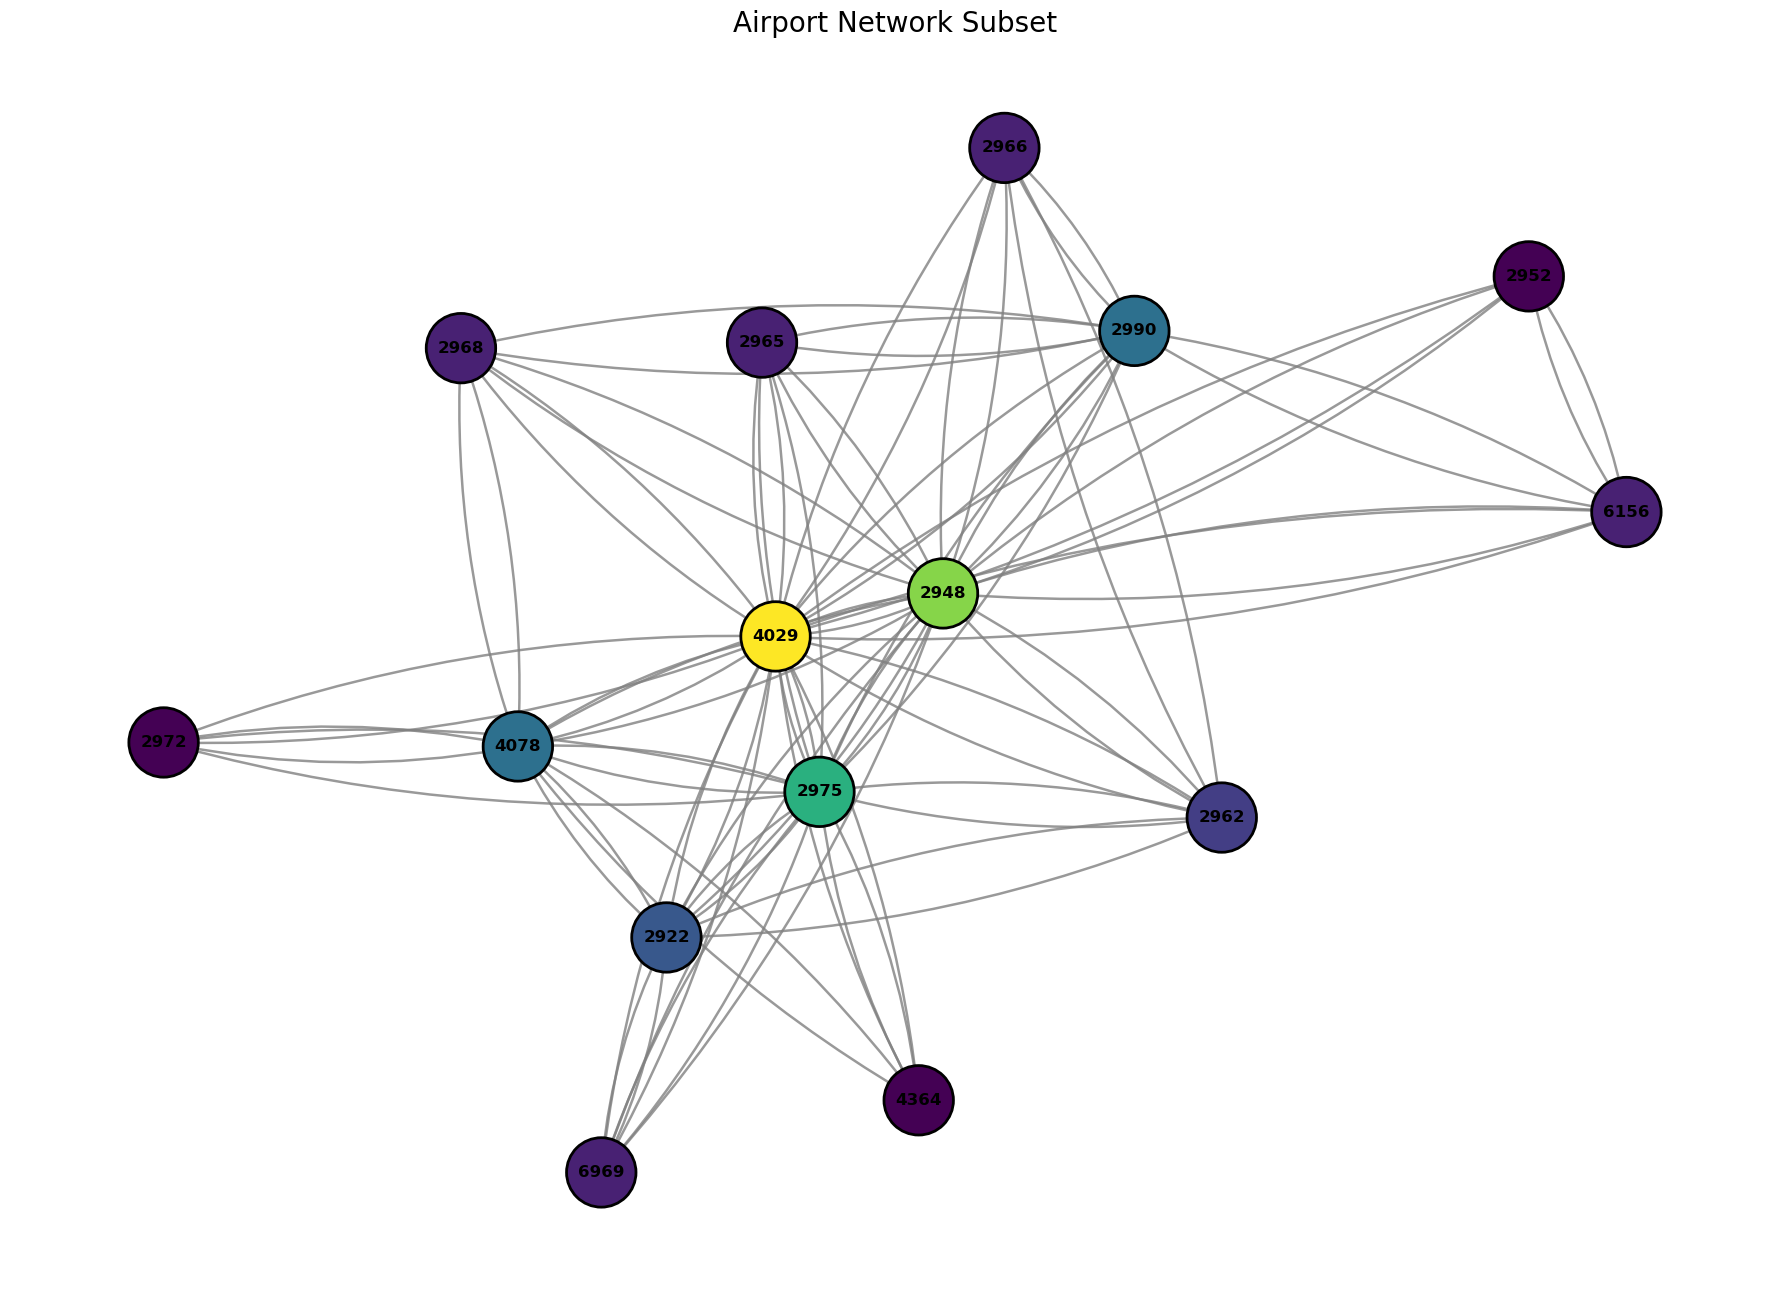

In [19]:
def plot_subset(graph_obj, n=15):
    G = nx.DiGraph()

    subset_ids = list(graph_obj.graph.keys())[:n]

    for u in subset_ids:
        for v, weight in graph_obj.graph.get(u, []):
            if v in subset_ids:
                G.add_edge(u, v, weight=weight)

    plt.figure(figsize=(18, 13))
    pos = nx.spring_layout(G, k=2.0, seed=42)

    degrees = dict(G.degree())
    node_colors = [degrees[node] for node in G.nodes()]

    nx.draw_networkx_nodes(
        G, pos,
        node_size=2500,
        node_color=node_colors,
        cmap="viridis",
        edgecolors="black",
        linewidths=2
    )

    nx.draw_networkx_edges(
        G, pos,
        arrowstyle='->',
        arrowsize=20,
        width=1.8,
        edge_color='gray',
        alpha=0.8,
        connectionstyle='arc3,rad=0.1'
    )

    labels = {node: str(node) for node in G.nodes()}

    nx.draw_networkx_labels(
        G, pos,
        labels=labels,
        font_size=12,
        font_weight='bold'
    )

    plt.title("Airport Network Subset", fontsize=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_subset(graph, n=15)
